# WEEK 9
# KNN Density Based Estimation

For a point $x_i$ find its $k$ nearest neighbor:

1. $k$ is the number of points the algorithm will select, small $k$ sensitive to noise, big $k$ may not capture the real frequency
2. Compute the distance to the $k$-th neighbor $r_k(x_i)$
    
    i. Small  $r_k$ neighbors are very close $\Rightarrow$ high density

    ii. Large  $r_k$ neighbors are far $\Rightarrow$ low density
3) Estimate the density

    i. $n$ = total number of points

    ii. $d$ = instrinsic dimension (manifold dimension)

    iii. $V_d$= volume of unit ball in dimensions

Big idea: The recripirocal of the density is proportional to $r_k(x_i)^d$


### KNN-Based Density Estimation and Weighted Distances

1. **Distance to k-th nearest neighbor**:

$$
r_k(x_i) = \text{distance from } x_i \text{ to its } k\text{-th nearest neighbor}
$$

2. **Density estimate**:

$$
\hat f(x_i) \approx \frac{k}{n \cdot V_d \cdot r_k(x_i)^d}
$$

where:  
- $n$ = total number of points  
- $d$ = intrinsic dimension of the manifold  
- $V_d$ = volume of the unit ball in \(d\) dimensions

3. **Reciprocal of the density**:

$$
\frac{1}{\hat f(x_i)} \propto r_k(x_i)^d
$$

4. **Weighted distance for Vietoris–Rips filtration**:

$$
D_w(i,j) = D(i,j) \cdot \frac{1}{\hat f(x_i)^{1/d}}
$$

or symmetrized:

$$
D_w(i,j) = D(i,j) \cdot \max \Big( \frac{1}{\hat f(x_i)^{1/d}}, \frac{1}{\hat f(x_j)^{1/d}} \Big)
$$

**Intuition:**  
- Dense regions ($\hat f$ large) → distances are increased → slows down over-connection  
- Sparse regions ($\hat f$ small) → distances are decreased → allows earlier connection

intuition:

Dense regions $\Rightarrow$ small $k$-th neighbor distance $\Rightarrow$ local distances are expanded

Sparse regions $\Rightarrow$ large $k$-th neighbor distance $\Rightarrow$ local distances are compressed

 Conceptually exactly the same as KDE, but parameterized by k instead of bandwidth $h$.

# KNN Compared to KDE Weighted
KDE FORMULA:
$$
D_w(i,j) = D(i,j) \cdot \hat f(x_i)^{-1/d}
$$
In KDE essentially, we were rescaling distances inversely proportional to local density, so it gave us a smooth estimate of $\hat{f}(x_i)$.
The KNN gives us an alternative we can use $r_k(x_i)^d$ as a local density proxy, then our weighted density.
$$
D_w(i,j) = D(i,j) \cdot r_k(x_i) \quad \text{(or some symmetrized version)}
$$

KDE VS KNN

Parameters: Bandwith($h$) vs number of neighbors $k$


Smoothness: Smooth density surface vs Piecewise point distances

Local adaption: Explicit Kernel vs implicit vis neighbor distances

KDE: Can over/undersmooth depending on k

KNN: Less senstivie, automatically adapts to local sparcity

Often KNN weighting is preferred for highly non-uniform or clustered data because it’s adaptive.

In [81]:
#Code necessary for example
import numpy as np
# Sample on a circle with half very dense
def sample_circle_half_dense(n, p_dense=0.8, seed=None):
    """
    n points on unit circle.
    p_dense fraction go to dense half: theta in [0, pi)
    rest go to sparse half: theta in [pi, 2pi)
    """
    rng = np.random.default_rng(seed)

    # choose which half each point comes from
    dense_mask = rng.random(n) < p_dense

    theta = np.empty(n)

    # de
    # nse half: [0, pi)
    theta[dense_mask] = rng.uniform(0.0, np.pi, dense_mask.sum())

    # sparse half: [pi, 2pi)
    theta[~dense_mask] = rng.uniform(np.pi, 2*np.pi, (~dense_mask).sum())

    X = np.column_stack([np.cos(theta), np.sin(theta)])
    return X, theta

import matplotlib.pyplot as plt 
def plot_circle_points(X):
    #Plot 2D points sampled on the circle.
    
    plt.figure()
    plt.scatter(X[:, 0], X[:, 1], s=10)
    plt.gca().set_aspect('equal', 'box')
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Half-Dense Circle")
    plt.show()

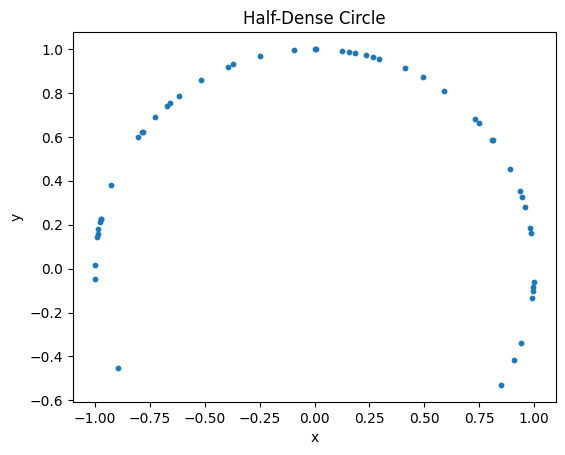

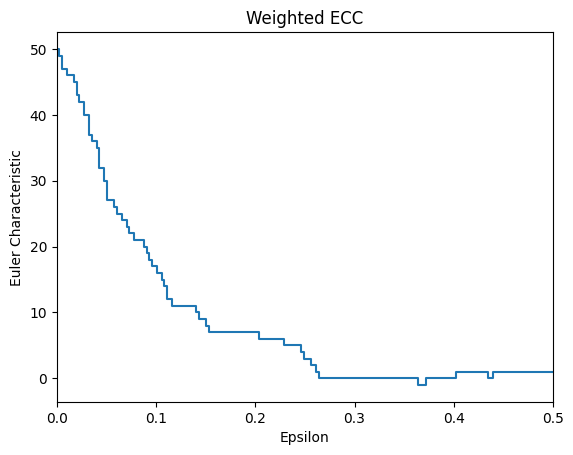

In [82]:
import ecc_vr as vr


X, theta = sample_circle_half_dense(
    n=50,        
    p_dense=0.85,   # x% in top half
    seed=0 
)
plot_circle_points(X)
D_w, _ = vr.weighted_distance_matrix_kde(X, h=0.08, d_manifold=1, sym_rule="min")
Cw = vr.local_contributions(X, epsilon=0.5, max_dim=None, D=D_w)
vr.plot_ECC_from_C(Cw, eps_min=0.0, eps_max=0.5, num=200, title="Weighted ECC")


In [83]:
def edge_stats(D, eps):
    A = (D <= eps)
    np.fill_diagonal(A, False)
    deg = A.sum(axis=1)
    m_edges = deg.sum() // 2
    return deg.mean(), m_edges

eps = 0.3
D = vr.pairwise_dist(X) 
degD, edgesD = edge_stats(D, eps)
degW, edgesW = edge_stats(D_w, eps)
print("avg degree D:", degD, "edges D:", edgesD)
print("avg degree W:", degW, "edges W:", edgesW)

def triangle_count(D, eps):
    A = (D <= eps).astype(int)
    np.fill_diagonal(A, 0)
    A3 = A @ A @ A
    return int(np.trace(A3) // 6)

print("triangles D:", triangle_count(D, eps))
print("triangles W:", triangle_count(D_w, eps))

avg degree D: 6.8 edges D: 170
avg degree W: 5.68 edges W: 142
triangles D: 273
triangles W: 166


In [84]:
#KDE packages
from sklearn.neighbors import KernelDensity
import numpy as np

def compute_kde_sklearn(X, bandwidth=0.2, kernel="gaussian"):
    """
    Compute KDE values at sample points using sklearn.
    """
    kde = KernelDensity(bandwidth=bandwidth, kernel=kernel)
    kde.fit(X)

    log_density = kde.score_samples(X)
    density = np.exp(log_density)

    return density

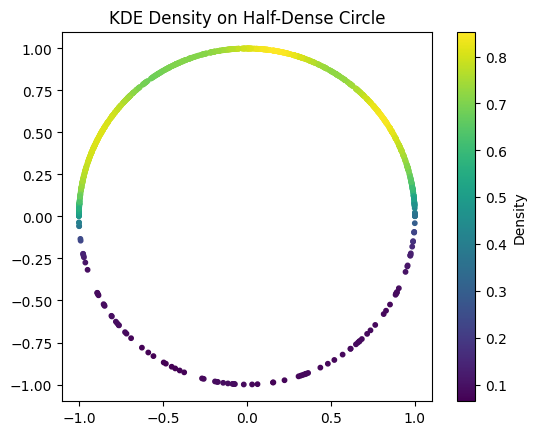

In [85]:
X, theta = sample_circle_half_dense(1000, p_dense=0.9, seed=42)

density = compute_kde_sklearn(X, bandwidth=0.15)

plt.figure()
plt.scatter(X[:,0], X[:,1], c=density, s=10)
plt.gca().set_aspect('equal')
plt.title("KDE Density on Half-Dense Circle")
plt.colorbar(label="Density")
plt.show()

In [86]:
def compute_weighted_eps(density, epsilon, d=1):
    return epsilon / (density ** (1/d))
epsilon = 0.2
eps_i = compute_weighted_eps(density, epsilon, d=1)

from sklearn.metrics import pairwise_distances
import networkx as nx
def adjacency_variable_eps(X, eps_i):
    D = pairwise_distances(X)
    n = len(X)
    A = np.zeros((n, n), dtype=int)

    for i in range(n):
        for j in range(n):
            if D[i,j] <= min(eps_i[i], eps_i[j]):
                A[i,j] = 1
    return A


def count_components(A):
    G = nx.from_numpy_array(A)
    return nx.number_connected_components(G)

# Fixed epsilon
A_fixed = adjacency_variable_eps(X, np.full(len(X), epsilon))
print("Components (fixed eps):", count_components(A_fixed))

# Weighted epsilon
A_weighted = adjacency_variable_eps(X, eps_i)
print("Components (weighted eps):", count_components(A_weighted))

Components (fixed eps): 1
Components (weighted eps): 1


In [87]:
from sklearn.neighbors import KernelDensity

def weighted_distance_sklearn(X, bandwidth=0.15, d_manifold=1, sym_rule="min"):
    X = np.asarray(X, dtype=float)

    # Base distances
    D = vr.pairwise_dist(X)

    # KDE from sklearn
    kde = KernelDensity(bandwidth=bandwidth, kernel="gaussian")
    kde.fit(X)
    log_density = kde.score_samples(X)
    f = np.exp(log_density)

    f = np.maximum(f, 1e-12)
    f = f / f.mean()
    s = f ** (1.0 / d_manifold)

    si = s[:, None]
    sj = s[None, :]

    rule = sym_rule.lower().strip()
    if rule == "min":
        scale = np.maximum(si, sj)
    elif rule == "max":
        scale = np.minimum(si, sj)
    elif rule in {"mean", "avg", "average"}:
        scale = (2.0 * si * sj) / (si + sj)
    else:
        raise ValueError("sym_rule must be 'min', 'max', or 'mean'")

    D_w = D * scale
    np.fill_diagonal(D_w, 0.0)
    return D_w, f

In [88]:
eps = 0.3

# Raw distance
D = vr.pairwise_dist(X)

# Custom Weighting
D_w_custom, _ = vr.weighted_distance_matrix_kde(X, h=0.08, d_manifold=1)

# Sklearn weighting
D_w_sklearn, _ = weighted_distance_sklearn(X, bandwidth=0.08, d_manifold=1)

# Edge Stats
deg_raw, edges_raw = edge_stats(D, eps)
deg_custom, edges_custom = edge_stats(D_w_custom, eps)
deg_sklearn, edges_sklearn = edge_stats(D_w_sklearn, eps)

print("RAW      -> avg degree:", deg_raw, "edges:", edges_raw)
print("CUSTOM   -> avg degree:", deg_custom, "edges:", edges_custom)
print("SKLEARN  -> avg degree:", deg_sklearn, "edges:", edges_sklearn)

# Triangles
print("triangles RAW:", triangle_count(D, eps))
print("triangles CUSTOM:", triangle_count(D_w_custom, eps))
print("triangles SKLEARN:", triangle_count(D_w_sklearn, eps))

RAW      -> avg degree: 152.112 edges: 76056
CUSTOM   -> avg degree: 137.898 edges: 68949
SKLEARN  -> avg degree: 137.898 edges: 68949
triangles RAW: 3188728
triangles CUSTOM: 2445869
triangles SKLEARN: 2445869


In [89]:
dense_mask = theta < np.pi
sparse_mask = ~dense_mask

def degree_split_stats(D, eps):
    A = (D <= eps)
    np.fill_diagonal(A, False)
    deg = A.sum(axis=1)

    return {
        "avg": deg.mean(),
        "dense_avg": deg[dense_mask].mean(),
        "sparse_avg": deg[sparse_mask].mean(),
        "gap": abs(deg[dense_mask].mean() - deg[sparse_mask].mean())
    }
bandwidths = [0.05, 0.08, 0.12, 0.2]
eps = 0.3

results = []

for h in bandwidths:
    D_w, f = vr.weighted_distance_matrix_kde(X, h=h, d_manifold=1)
    stats = degree_split_stats(D_w, eps)
    triangles = triangle_count(D_w, eps)

    results.append((h, stats, triangles))

for h, stats, triangles in results:
    print(f"\nBandwidth h = {h}")
    print("Avg degree:", stats["avg"])
    print("Dense avg:", stats["dense_avg"])
    print("Sparse avg:", stats["sparse_avg"])
    print("Gap:", stats["gap"])
    print("Triangles:", triangles)


Bandwidth h = 0.05
Avg degree: 137.234
Dense avg: 142.22062084257206
Sparse avg: 91.33673469387755
Gap: 50.883886148694515
Triangles: 2433703

Bandwidth h = 0.08
Avg degree: 137.898
Dense avg: 142.76718403547673
Sparse avg: 93.08163265306122
Gap: 49.68555138241551
Triangles: 2445869

Bandwidth h = 0.12
Avg degree: 138.152
Dense avg: 143.34146341463415
Sparse avg: 90.38775510204081
Gap: 52.953708312593335
Triangles: 2453335

Bandwidth h = 0.2
Avg degree: 138.056
Dense avg: 144.14745011086475
Sparse avg: 81.98979591836735
Gap: 62.157654192497404
Triangles: 2460565


In [90]:
#Coded Example
from sklearn.neighbors import NearestNeighbors
import numpy as np

def knn_reciprocal_density(X, k=5):
    n, d = X.shape
    nbrs = NearestNeighbors(n_neighbors=k+1).fit(X)
    distances, indices = nbrs.kneighbors(X)
    # distances[:,0] = 0 (distance to self), use k-th neighbor
    r_k = distances[:, k]
    # reciprocal density estimate
    return r_k ** d  # proportional to 1/f


In [91]:
s = knn_reciprocal_density(X, k=5)
s /= np.mean(s)  # normalize globally
D_w = vr.pairwise_dist(X) * np.maximum(s[:, None], s[None, :])

In [92]:
X, theta = sample_circle_half_dense(n=101, p_dense=0.80, seed=0)
D = vr.pairwise_dist(X)

In [93]:
import numpy as np

#KNN-based density estimate
def knn_reciprocal_weights_normalized(X, k=5, d_manifold=1, sym_rule="max"):
    n = X.shape[0]
    D = vr.pairwise_dist(X)  # shape (n, n)
    
    # ignore self-distances
    D_no_diag = D.copy()
    np.fill_diagonal(D_no_diag, np.inf)
    
    # sort each row
    sorted_dist = np.sort(D_no_diag, axis=1)
    
    # k-th nearest neighbor
    if k < 1 or k > n-1:
        raise ValueError(f"k={k} is out of bounds for n={n}")
    r_k = sorted_dist[:, k-1]  # shape (n,)
    
    # normalize
    r_k_normalized = r_k / np.mean(r_k)
    
    # construct scaling matrix
    si = r_k_normalized[:, None]   # (n,1)
    sj = r_k_normalized[None, :]   # (1,n)
    
    if sym_rule.lower() == "min":
        scale = np.maximum(si, sj)
    elif sym_rule.lower() == "max":
        scale = np.minimum(si, sj)
    elif sym_rule.lower() in {"mean", "avg", "average"}:
        scale = 2*si*sj/(si+sj)
    else:
        raise ValueError("sym_rule must be 'min', 'max', or 'mean'")
    
    # weighted distance
    D_w = D * scale      # shape (n,n) 
    np.fill_diagonal(D_w, 0.0)
    
    return D_w, r_k

RAW      -> avg degree: 2.933333333333333 edges: 44
CUSTOM   -> avg degree: 5.266666666666667 edges: 79
SKLEARN  -> avg degree: 5.266666666666667 edges: 79
KNN      -> avg degree: 11.933333333333334 edges: 179
triangles RAW: 30
triangles CUSTOM: 87
triangles SKLEARN: 87
triangles KNN: 597


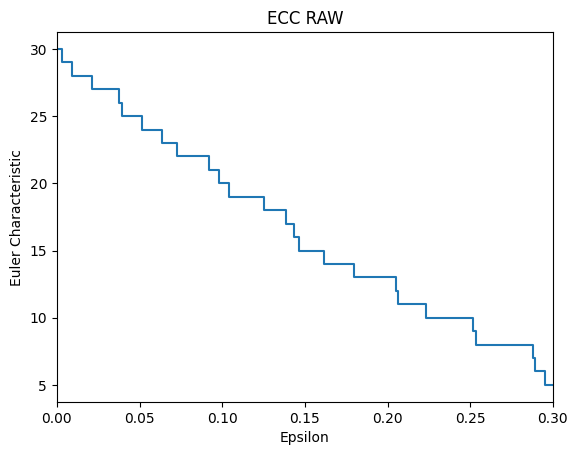

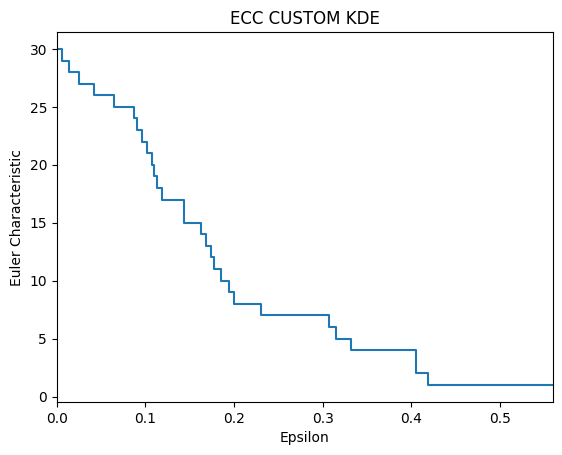

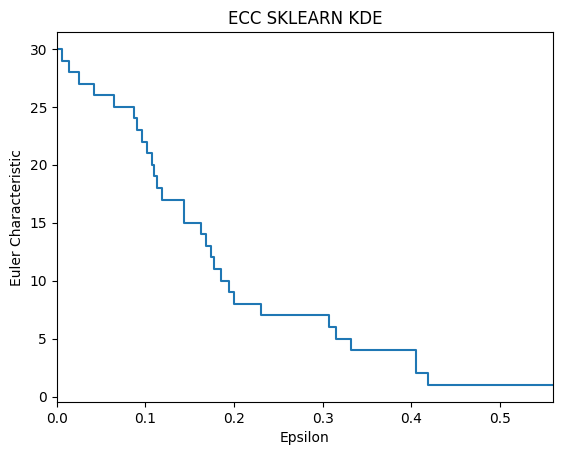

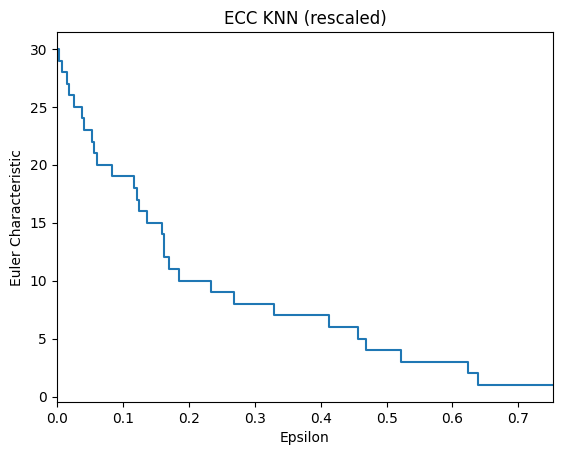

In [99]:
# Step 1: Raw distances
X, theta = sample_circle_half_dense(n=30, p_dense=0.75, seed=0)
D = vr.pairwise_dist(X)  # raw

# Step 2: KDE-based weighted distances
D_w_custom, _ = vr.weighted_distance_matrix_kde(X, h=0.08, d_manifold=1)  # custom
D_w_sklearn, _ = weighted_distance_sklearn(X, bandwidth=0.08, d_manifold=1)  # sklearn KDE

# Step 3: KNN-based weighted distances
D_w_knn, r_k = knn_reciprocal_weights_normalized(X, k=2, d_manifold=1)

# Step 4: Rescale KNN distances to match raw scale
D_w_knn_rescaled = D_w_knn / np.mean(D_w_knn) * np.mean(D)

# Step 5: Set epsilon and scale for direct comparison
eps_base = 0.3

# Scale epsilon by ratio of max distances to maintain comparable probe size
eps_scaled_custon = eps_base * (D_w_custom.max() / D.max())
eps_sclaed_sklearn = eps_base * (D_w_sklearn.max() / D.max())
eps_scaled_knn = eps_base * (D_w_knn_rescaled.max() / D.max())

# tep 6: Edge stats
deg_raw, edges_raw = edge_stats(D, eps)
deg_custom, edges_custom = edge_stats(D_w_custom, eps_scaled_custon)
deg_sklearn, edges_sklearn = edge_stats(D_w_sklearn, eps_sclaed_sklearn)
deg_knn, edges_knn = edge_stats(D_w_knn_rescaled, eps_scaled_knn)

print("RAW      -> avg degree:", deg_raw, "edges:", edges_raw)
print("CUSTOM   -> avg degree:", deg_custom, "edges:", edges_custom)
print("SKLEARN  -> avg degree:", deg_sklearn, "edges:", edges_sklearn)
print("KNN      -> avg degree:", deg_knn, "edges:", edges_knn)

# Step 7: Triangle counts
print("triangles RAW:", triangle_count(D, eps))
print("triangles CUSTOM:", triangle_count(D_w_custom, eps_scaled_custon))
print("triangles SKLEARN:", triangle_count(D_w_sklearn, eps_sclaed_sklearn))
print("triangles KNN:", triangle_count(D_w_knn_rescaled, eps_scaled_knn))



# Step 8: ECC plots
C_raw = vr.local_contributions(X, epsilon=eps, max_dim=None, D=D)
C_custom = vr.local_contributions(X, epsilon=eps_scaled_custon, max_dim=None, D=D_w_custom)
C_sklearn = vr.local_contributions(X, epsilon=eps_sclaed_sklearn, max_dim=None, D=D_w_sklearn)
C_knn = vr.local_contributions(X, epsilon=eps_scaled_knn, max_dim=None, D=D_w_knn_rescaled)

vr.plot_ECC_from_C(C_raw, eps_min=0, eps_max=eps, title="ECC RAW")
vr.plot_ECC_from_C(C_custom, eps_min=0, eps_max=eps_scaled_custon, title="ECC CUSTOM KDE")
vr.plot_ECC_from_C(C_sklearn, eps_min=0, eps_max=eps_sclaed_sklearn, title="ECC SKLEARN KDE")
vr.plot_ECC_from_C(C_knn, eps_min=0, eps_max=eps_scaled_knn, title="ECC KNN (rescaled)")

All graphs interpret the same geometrical filtration on the circle.